# Purchasing Cycle Comparison

The inventory replenishment team wants to compare the typical purchasing cycles associated with Produce and Alcohol.

## Load the data

Load the order history, prior purchases, product information, and department labels needed for the comparison.

In [11]:
import matplotlib.pyplot as plt
import pandas as pd


DATA_DIR = "../../data/shop"

orders = pd.read_csv(
    f"{DATA_DIR}/orders.csv",
    usecols=[
        "order_id",
        "user_id",
        "order_number",
        "days_since_prior_order",
    ],
)

order_products = pd.read_csv(
    f"{DATA_DIR}/order_products__prior.csv",
    usecols=[
        "order_id",
        "product_id",
    ],
)

products = pd.read_csv(
    f"{DATA_DIR}/products.csv",
    usecols=[
        "product_id",
        "department_id",
    ],
)

departments = pd.read_csv(
    f"{DATA_DIR}/departments.csv",
)

orders.head()

,order_id,user_id,order_number,days_since_prior_order
0,2539329,1,1,NaN
1,2398795,1,2,15.0
2,473747,1,3,21.0
3,2254736,1,4,29.0
4,431534,1,5,28.0


## Identify Produce and Alcohol orders

Map purchased products to departments and identify prior orders containing Produce or Alcohol.

In [12]:
department_orders = (
    order_products
    .merge(
        products,
        on="product_id",
    )
    .merge(
        departments,
        on="department_id",
    )
    .query(
        "department in ['produce', 'alcohol']"
    )
    [
        ["order_id", "department"]
    ]
    .drop_duplicates()
    .merge(
        orders,
        on="order_id",
    )
)


print(
    department_orders
    .groupby("department")["order_id"]
    .nunique()
)

department
alcohol      84689
produce    2409320
Name: order_id, dtype: int64


## Define purchasing cycle

"Purchasing cycle" can reasonably refer to different temporal patterns.

This analysis compares two operational definitions:

- **Prior-order interval:** the number of days since the shopper's previous Instacart order when a Produce or Alcohol purchase occurs.
- **Same-department repurchase cycle:** the number of days between successive purchases from the same department.

Both definitions are measured in days but answer different versions of the business question.

In [13]:
# Definition 1:
# Mean interval before orders containing the department.

prior_interval = (
    department_orders
    .dropna(
        subset=["days_since_prior_order"]
    )
    .groupby("department")
    ["days_since_prior_order"]
    .mean()
)


print(
    "Prior-order interval:"
)

print(
    prior_interval
    .round(2)
)

Prior-order interval:
department
alcohol    10.15
produce    10.62
Name: days_since_prior_order, dtype: float64


## Calculate same-department repurchase cycles

Reconstruct each shopper's order timeline and calculate the time between consecutive purchases from the same department.

In [14]:
orders_timeline = (
    orders
    .sort_values(
        ["user_id", "order_number"]
    )
    .copy()
)

orders_timeline[
    "days_since_prior_order"
] = (
    orders_timeline[
        "days_since_prior_order"
    ]
    .fillna(0)
)

orders_timeline["shopping_day"] = (
    orders_timeline
    .groupby("user_id")
    ["days_since_prior_order"]
    .cumsum()
)


department_history = (
    department_orders[
        [
            "order_id",
            "department",
        ]
    ]
    .merge(
        orders_timeline[
            [
                "order_id",
                "user_id",
                "order_number",
                "shopping_day",
            ]
        ],
        on="order_id",
    )
    .sort_values(
        [
            "department",
            "user_id",
            "order_number",
        ]
    )
)


department_history[
    "department_cycle_days"
] = (
    department_history
    .groupby(
        [
            "department",
            "user_id",
        ]
    )["shopping_day"]
    .diff()
)


same_department_cycles = (
    department_history
    .dropna(
        subset=["department_cycle_days"]
    )
)


same_department_summary = (
    same_department_cycles
    .groupby("department")
    ["department_cycle_days"]
    .agg(
        cycle_count="count",
        typical_cycle_days="mean",
    )
)


print(
    "Same-department repurchase cycle:"
)

print(
    same_department_summary
    .round(2)
)

Same-department repurchase cycle:
            cycle_count  typical_cycle_days
department                                 
alcohol           68891               15.99
produce         2216083               12.50


## Compare the definitions

Compare the purchasing-cycle estimates produced by the two operational definitions.

department             alcohol  produce
Prior-order interval     10.15    10.62
Same-department cycle    15.99    12.50


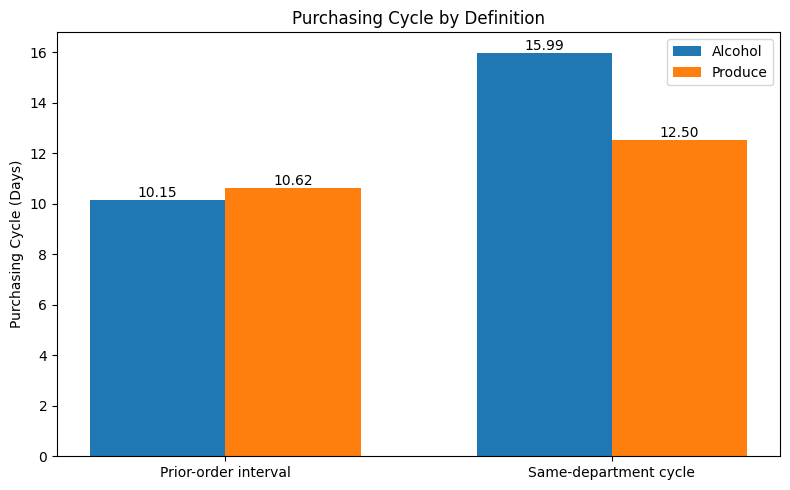

In [15]:
comparison = pd.DataFrame({
    "Prior-order interval": prior_interval,
    "Same-department cycle":
        same_department_summary[
            "typical_cycle_days"
        ],
}).T


print(
    comparison
    .round(2)
)


plot_data = (
    comparison
    .reset_index(
        names="definition"
    )
)


fig, ax = plt.subplots(
    figsize=(8, 5)
)

x = range(
    len(plot_data)
)

width = 0.35


bars_alcohol = ax.bar(
    [
        value - width / 2
        for value in x
    ],
    plot_data["alcohol"],
    width,
    label="Alcohol",
)

bars_produce = ax.bar(
    [
        value + width / 2
        for value in x
    ],
    plot_data["produce"],
    width,
    label="Produce",
)


ax.set_xticks(
    list(x),
    plot_data["definition"],
)

ax.set_ylabel(
    "Purchasing Cycle (Days)"
)

ax.set_title(
    "Purchasing Cycle by Definition"
)

ax.legend()


for bars in [
    bars_alcohol,
    bars_produce,
]:
    for bar in bars:
        value = bar.get_height()

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            value,
            f"{value:.2f}",
            ha="center",
            va="bottom",
        )


plt.tight_layout()
plt.show()

## Conclusion

The comparison changes depending on how purchasing cycle is defined.

- Using the interval before orders containing the department, **Alcohol has the shorter cycle**: 10.15 days versus 10.62 days for Produce.
- Using the time between successive purchases from the same department, **Produce has the shorter cycle**: 12.50 days versus 15.99 days for Alcohol.

The two reasonable operational definitions therefore lead to different conclusions, so the intended meaning of purchasing cycle should be specified before selecting a single result.